In [1]:
#!/usr/bin/env python3
"""
Build the CareSpace synthetic database.

  python3 data/seed.py

Writes:
  data/carespace.db          SQLite, schema from data/schema.sql
  app/src/lib/fixture.json   same data as JSON so the UI runs before the DB is wired

Two zones: shelf-stable and produce. No frozen. Most partner agencies in this
network run out of a fellowship hall or a storage closet, and a cold chain is
the thing they do not have.

Partner agencies only. The Miramar warehouse is the mother kitchen and belongs
to the allocation problem, not to mapping what a pantry can hold.

Everything here is synthetic and authored for the demo. Agency names and
addresses are drawn from the public San Diego Food Bank partner list. Every
capacity, item, volume, and count below was written by hand to make the
constraint visible. See data/README.md.
"""

import json
import os
import sqlite3
import uuid

TODAY = "2026-08-21"
ROOT = r"C:\Users\alexh\Python\Data Science Alliance Hackathon"
DB_PATH = os.path.join(ROOT, "data", "carespace.db")
SCHEMA_PATH = os.path.join(ROOT, "schema.sql")          # <-- no "data"
FIXTURE_PATH = os.path.join(ROOT, "app", "src", "lib", "fixture.json")
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)
os.makedirs(os.path.dirname(FIXTURE_PATH), exist_ok=True)


def rid(prefix):
    return f"{prefix}_{uuid.uuid4().hex[:8]}"


# ---------------------------------------------------------------------------
# Reference
# ---------------------------------------------------------------------------

ZONES = [
    ("shelf_stable", "Shelf-stable", 50, 80, 1),
    ("produce", "Produce", 33, 40, 2),
]

# typical_cuft is the prior the scan falls back on when it recognizes the form
# factor but cannot size it confidently.
# usable_default is the fit factor: how much of the box you can actually stack
# into once you account for aisles, air gaps, and the shelf nobody can reach.
KINDS = [
    ("pallet_rack",        "Pallet rack bay",    "shelf_stable",  64.0, 0.70, 0),
    ("wire_shelving",      "Wire shelving unit", "shelf_stable",  18.0, 0.75, 0),
    ("pantry_closet",      "Pantry closet",      "shelf_stable",  45.0, 0.70, 1),
    ("floor_stack",        "Floor staging area", "shelf_stable",  30.0, 0.60, 0),
    ("reach_in_cooler",    "Reach-in cooler",    "produce",       24.0, 0.75, 0),
    ("walk_in_cooler",     "Walk-in cooler",     "produce",      120.0, 0.65, 1),
    ("residential_fridge", "Residential fridge", "produce",       20.0, 0.60, 0),
]

# ---------------------------------------------------------------------------
# Item catalog. unit_volume_cuft is the field that makes the whole product work.
# Note how badly weight predicts volume: a case of diapers is 40 lb / 3.5 cuft,
# a case of canned corn is 11 lb / 0.45 cuft.
# ---------------------------------------------------------------------------

ITEMS = [
    # id, name, category, zone, unit_description, lb, cuft
    ("rice_white",    "White Rice",             "Grains/Staples",  "shelf_stable", "25 lb bag",           25.0, 0.55),
    ("beans_pinto",   "Dried Pinto Beans",      "Grains/Staples",  "shelf_stable", "20 lb bag",           20.0, 0.45),
    ("oats",          "Rolled Oats",            "Grains/Staples",  "shelf_stable", "10 lb bag",           10.0, 0.35),
    ("pasta_spag",    "Spaghetti Pasta",        "Grains/Staples",  "shelf_stable", "case of 24 (16oz)",   24.0, 0.90),
    ("cereal",        "Cereal (Assorted)",      "Grains/Staples",  "shelf_stable", "case of 12",          15.0, 1.60),
    ("cn_blackbean",  "Canned Black Beans",     "Canned Goods",    "shelf_stable", "case of 12 (15oz)",   11.3, 0.45),
    ("cn_corn",       "Canned Corn",            "Canned Goods",    "shelf_stable", "case of 12 (15oz)",   11.3, 0.45),
    ("cn_tomato",     "Canned Diced Tomatoes",  "Canned Goods",    "shelf_stable", "case of 12 (14.5oz)", 11.0, 0.45),
    ("cn_tuna",       "Canned Tuna",            "Canned Goods",    "shelf_stable", "case of 24 (5oz)",     8.0, 0.35),
    ("cn_chicken",    "Canned Chicken",         "Canned Goods",    "shelf_stable", "case of 12 (12.5oz)", 10.5, 0.42),
    ("peanut_butter", "Peanut Butter",          "Canned Goods",    "shelf_stable", "case of 12 (18oz)",   14.0, 0.55),
    ("veg_oil",       "Vegetable Oil",          "Canned Goods",    "shelf_stable", "case of 6 (48oz)",    20.0, 0.55),
    ("water",         "Bottled Water",          "Beverages",       "shelf_stable", "case of 24 (16.9oz)", 28.0, 0.75),
    ("diapers_4",     "Diapers (Size 4)",       "Household/Other", "shelf_stable", "case of 132",         40.0, 3.50),
    ("pads",          "Period Supplies (Pads)", "Household/Other", "shelf_stable", "case of 250",         18.0, 1.50),

    ("produce_box",   "Mixed Produce Box",      "Produce", "produce", "25-30 lb box", 27.0, 1.20),
    ("apples",        "Fresh Apples",           "Produce", "produce", "30 lb case",   30.0, 1.15),
    ("oranges",       "Fresh Oranges",          "Produce", "produce", "30 lb case",   30.0, 1.15),
    ("carrots",       "Fresh Carrots",          "Produce", "produce", "25 lb bag",    25.0, 0.95),
    ("potatoes",      "Fresh Potatoes",         "Produce", "produce", "30 lb bag",    30.0, 1.05),
    ("onions",        "Fresh Onions",           "Produce", "produce", "25 lb bag",    25.0, 0.90),
    ("salad",         "Bagged Salad Mix",       "Produce", "produce", "case of 4 lb",  4.0, 0.60),
]

# ---------------------------------------------------------------------------
# The box. Quantities are fractions of a case, because a family gets consumer
# units out of a bulk case. consumer_qty is what the label says.
# Protein is canned, since there is no cold chain for meat.
# ---------------------------------------------------------------------------

BOX = {
    "id": "family_box",
    "name": "Family Box",
    "feeds_people": 4,
    "feeds_days": 7,
    "description": "One week of balanced meals for a household of four. Must be assembled at a single site.",
}

BOX_LINES = [
    # item, qty_units (fraction of a case), consumer_qty
    ("rice_white",    0.400, "10 lb rice"),
    ("beans_pinto",   0.100, "2 lb dried beans"),
    ("cn_blackbean",  0.333, "4 cans black beans"),
    ("cn_corn",       0.167, "2 cans corn"),
    ("cn_tomato",     0.167, "2 cans diced tomatoes"),
    ("cn_chicken",    0.167, "2 cans chicken"),
    ("cn_tuna",       0.083, "1 can tuna"),
    ("peanut_butter", 0.083, "1 jar peanut butter"),
    ("pasta_spag",    0.083, "1 lb pasta"),
    ("cereal",        0.083, "1 box cereal"),
    ("veg_oil",       0.167, "1 bottle cooking oil"),

    ("produce_box",   0.500, "Half a mixed produce box"),
    ("carrots",       0.080, "2 lb carrots"),
]

# ---------------------------------------------------------------------------
# Sites. Storage units are authored so the binding zone differs by site.
# (kind_id, label, gross_cuft, source, confidence, measured_at)
# usable_pct comes from the kind's default.
# ---------------------------------------------------------------------------

AGENCIES = [
    {
        "id": "oceanside_crc",
        "name": "Oceanside Community Resource Center",
        "address": "605 South Coast Highway", "city": "Oceanside", "zip": "92054",
        "service_type": "Food To Nonprofit",
        "food_category": "Nonperishable Dry Goods + Produce",
        "eligibility": "Open to All", "distribution_day": "Tuesday", "frequency": "Weekly",
        "start_time": "9:00 am", "end_time": "1:00 pm",
        "walkup": 1, "drivethru": 1, "diapers_period_supplies": 1,
        "weekend_availability": 0, "is_hub": 0,
        "story": "Warehouse-grade shelving, one break room fridge. The cheapest fix in the network is here.",
        "units": [
            ("pallet_rack",        "Pallet rack, bay 1",  64.0, "scan", 0.92, TODAY),
            ("pallet_rack",        "Pallet rack, bay 2",  64.0, "scan", 0.92, TODAY),
            ("pallet_rack",        "Pallet rack, bay 3",  64.0, "scan", 0.90, TODAY),
            ("floor_stack",        "Floor staging, dock", 30.0, "scan", 0.68, TODAY),
            ("residential_fridge", "Break room fridge",   20.0, "scan", 0.81, TODAY),
        ],
        "inventory": [
            ("rice_white", 24), ("beans_pinto", 20), ("pasta_spag", 14),
            ("cn_corn", 30), ("cn_tuna", 18), ("cn_chicken", 16), ("water", 28),
            ("diapers_4", 6),
            ("produce_box", 5), ("potatoes", 1),
        ],
    },
    {
        "id": "apostolic_escondido",
        "name": "Apostolic Assembly Church",
        "address": "1717 East Lincoln Avenue", "city": "Escondido", "zip": "92027",
        "service_type": "Neighborhood Distribution",
        "food_category": "Neighborhood Produce (25-30lb)",
        "eligibility": None, "distribution_day": "Saturday", "frequency": "Monthly",
        "start_time": "9:30 am", "end_time": "10:30 am",
        "walkup": 0, "drivethru": 1, "diapers_period_supplies": 1,
        "weekend_availability": 1, "is_hub": 0,
        "story": "A full pallet rack held back by the kitchen fridge.",
        "units": [
            ("pallet_rack",        "Pallet rack, bay 1",      64.0, "scan", 0.91, TODAY),
            ("pallet_rack",        "Pallet rack, bay 2",      64.0, "scan", 0.91, TODAY),
            ("wire_shelving",      "Shelving, supply closet", 18.0, "scan", 0.77, TODAY),
            ("residential_fridge", "Kitchen fridge",          20.0, "scan", 0.85, TODAY),
        ],
        "inventory": [
            ("rice_white", 10), ("cn_corn", 16), ("cn_tomato", 12),
            ("pasta_spag", 8), ("cn_chicken", 10), ("cereal", 6),
            ("diapers_4", 18), ("pads", 8),
            ("produce_box", 8),
        ],
    },
    {
        "id": "all_saint_vista",
        "name": "All Saint Episcopal Church",
        "address": "651 Eucalyptus Avenue", "city": "Vista", "zip": "92084",
        "service_type": "Food To Nonprofit",
        "food_category": "Nonperishable Dry Goods + Produce",
        "eligibility": "Open to All", "distribution_day": "Saturday", "frequency": "Monthly",
        "start_time": "11:00 am", "end_time": "12:00 pm",
        "walkup": 0, "drivethru": 0, "diapers_period_supplies": 0,
        "weekend_availability": 1, "is_hub": 0,
        "story": "Inherited a walk-in cooler from a closed restaurant. Most of it sits empty, because the box also needs shelf space.",
        "units": [
            ("wire_shelving",  "Shelving, fellowship hall north wall",  18.0, "scan", 0.88, TODAY),
            ("wire_shelving",  "Shelving, fellowship hall south wall",  18.0, "scan", 0.88, TODAY),
            ("wire_shelving",  "Shelving, hallway",                     18.0, "scan", 0.81, TODAY),
            ("wire_shelving",  "Shelving, kitchen pantry",              18.0, "scan", 0.79, TODAY),
            ("walk_in_cooler", "Walk-in cooler, kitchen",              120.0, "scan", 0.92, TODAY),
        ],
        "inventory": [
            ("rice_white", 14), ("beans_pinto", 10), ("pasta_spag", 8),
            ("cereal", 4), ("cn_blackbean", 12), ("cn_corn", 10),
            ("cn_chicken", 6), ("peanut_butter", 4),
            ("produce_box", 22), ("carrots", 6), ("apples", 5),
        ],
    },
    {
        "id": "vida_nueva_cv",
        "name": "Iglesia Cristiana Vida Nueva",
        "address": "1240 Third Avenue", "city": "Chula Vista", "zip": "91911",
        "service_type": "Neighborhood Distribution",
        "food_category": "Nonperishable Dry Goods + Produce",
        "eligibility": "Open to All", "distribution_day": "Wednesday", "frequency": "Weekly",
        "start_time": "4:00 pm", "end_time": "6:00 pm",
        "walkup": 1, "drivethru": 0, "diapers_period_supplies": 0,
        "weekend_availability": 0, "is_hub": 0,
        "story": "The most balanced site in the network. Little stranded space either way.",
        "units": [
            ("wire_shelving",   "Shelving, pantry room", 18.0, "scan", 0.93, TODAY),
            ("wire_shelving",   "Shelving, pantry room", 18.0, "scan", 0.93, TODAY),
            ("wire_shelving",   "Shelving, pantry room", 18.0, "scan", 0.88, TODAY),
            ("reach_in_cooler", "Reach-in cooler",       24.0, "scan", 0.90, TODAY),
        ],
        "inventory": [
            ("rice_white", 8), ("beans_pinto", 6), ("cn_blackbean", 10),
            ("cereal", 3), ("cn_chicken", 5), ("pasta_spag", 5),
            ("peanut_butter", 4), ("veg_oil", 3),
            ("produce_box", 8), ("apples", 2),
        ],
    },
    {
        "id": "aguilas_sd",
        "name": "Aguilas del Poderoso Dios",
        "address": "5901 Rancho Hills Drive", "city": "San Diego", "zip": "92139",
        "service_type": "Neighborhood Distribution",
        "food_category": "Neighborhood Produce (25-30lb)",
        "eligibility": "Open to All", "distribution_day": "Thursday", "frequency": "Monthly",
        "start_time": "10:00 am", "end_time": "until food runs out",
        "walkup": 1, "drivethru": 1, "diapers_period_supplies": 0,
        "weekend_availability": 0, "is_hub": 0,
        "story": "No cold storage at all. Produce arrives the morning of and is handed out the same day, so nothing can be held.",
        "units": [
            ("wire_shelving", "Shelving, storage room", 18.0, "scan", 0.90, TODAY),
            ("wire_shelving", "Shelving, storage room", 18.0, "scan", 0.90, TODAY),
            ("wire_shelving", "Shelving, back office",  18.0, "scan", 0.72, TODAY),
        ],
        "inventory": [
            ("rice_white", 6), ("cn_corn", 12), ("cn_blackbean", 10),
            ("cn_chicken", 8), ("pasta_spag", 4), ("oats", 4),
        ],
    },
]

OPERATORS = [
    ("op_maria",  "Maria Delgado",  "agency_rep",         "all_saint_vista"),
    ("op_javier", "Javier Ruiz",    "agency_rep",         "aguilas_sd"),
    ("op_grace",  "Grace Okonkwo",  "agency_rep",         "apostolic_escondido"),
    ("op_dan",    "Dan Whitmore",   "logistics_operator", None),
]


def build():
    if os.path.exists(DB_PATH):
        os.remove(DB_PATH)
    con = sqlite3.connect(DB_PATH)
    con.executescript(open(SCHEMA_PATH).read())

    con.executemany("INSERT INTO storage_zone VALUES (?,?,?,?,?)", ZONES)
    con.executemany("INSERT INTO storage_unit_kind VALUES (?,?,?,?,?,?)", KINDS)
    con.executemany("INSERT INTO item VALUES (?,?,?,?,?,?,?,'synthetic')", ITEMS)
    con.execute(
        "INSERT INTO box_template VALUES (?,?,?,?,?)",
        (BOX["id"], BOX["name"], BOX["feeds_people"], BOX["feeds_days"], BOX["description"]),
    )
    con.executemany(
        "INSERT INTO box_line VALUES (?,?,?,?,?)",
        [(rid("bl"), BOX["id"], it, q, cq) for it, q, cq in BOX_LINES],
    )

    kind_zone = {k[0]: k[2] for k in KINDS}
    kind_usable = {k[0]: k[4] for k in KINDS}

    for a in AGENCIES:
        con.execute(
            "INSERT INTO agency VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,'synthetic')",
            (a["id"], a["name"], a["address"], a["city"], a["zip"], a["service_type"],
             a["food_category"], a["eligibility"], a["distribution_day"], a["frequency"],
             a["start_time"], a["end_time"], a["walkup"], a["drivethru"],
             a["diapers_period_supplies"], a["weekend_availability"], a["is_hub"]),
        )

        zone_totals, zone_source = {}, {}
        for kind, label, gross, source, conf, measured in a["units"]:
            zone = kind_zone[kind]
            usable = kind_usable[kind]
            con.execute(
                "INSERT INTO storage_unit VALUES (?,?,?,?,?,?,?,?,?,?,?,1,?,?)",
                (rid("su"), a["id"], zone, kind, label, gross, usable, source, conf,
                 None, None, measured, TODAY),
            )
            zone_totals[zone] = zone_totals.get(zone, 0.0) + gross * usable
            zone_source[zone] = source if zone not in zone_source else (
                zone_source[zone] if zone_source[zone] == source else "manual"
            )

        # A zone with no storage unit still gets a snapshot, at zero. That is a
        # real answer, not missing data, and the UI has to say so out loud.
        for zid, *_ in ZONES:
            con.execute(
                "INSERT INTO capacity_snapshot VALUES (?,?,?,?,?,?,?,?,NULL)",
                (rid("cap"), a["id"], zid, round(zone_totals.get(zid, 0.0), 2),
                 zone_source.get(zid, "manual"), None, TODAY, None),
            )

        for item_id, qty in a["inventory"]:
            con.execute("INSERT INTO inventory VALUES (?,?,?,?,?,?)",
                        (rid("inv"), a["id"], item_id, qty, None, None))

    con.executemany("INSERT INTO operator VALUES (?,?,?,?)", OPERATORS)
    con.commit()

    fixture = export_fixture(con)
    os.makedirs(os.path.dirname(FIXTURE_PATH), exist_ok=True)
    with open(FIXTURE_PATH, "w") as f:
        json.dump(fixture, f, indent=2)
    con.close()
    return fixture


def export_fixture(con):
    con.row_factory = sqlite3.Row
    q = lambda sql, *p: [dict(r) for r in con.execute(sql, p).fetchall()]

    demand = {
        r["zone_id"]: {"cuft_per_box": round(r["cuft_per_box"], 4),
                       "lb_per_box": round(r["lb_per_box"], 2)}
        for r in q("SELECT * FROM v_box_zone_demand WHERE template_id = ?", BOX["id"])
    }

    agencies = []
    for a in q("SELECT * FROM agency ORDER BY is_hub DESC, name"):
        cap = {r["zone_id"]: r for r in q(
            "SELECT * FROM v_current_capacity WHERE agency_id = ?", a["id"])}
        zones = []
        for zid, label, *_ in ZONES:
            usable = cap[zid]["usable_cuft"] if zid in cap else 0.0
            per_box = demand.get(zid, {}).get("cuft_per_box", 0)
            zones.append({
                "zone_id": zid,
                "label": label,
                "usable_cuft": round(usable, 1),
                "cuft_per_box": per_box,
                "boxes_if_alone": int(usable / per_box) if per_box else 0,
                "source": cap[zid]["source"] if zid in cap else "manual",
                "measured_at": cap[zid]["measured_at"] if zid in cap else None,
            })
        binding = min(zones, key=lambda z: z["boxes_if_alone"])
        holds = binding["boxes_if_alone"]
        for z in zones:
            z["is_binding"] = z["zone_id"] == binding["zone_id"]
            z["dead_boxes"] = z["boxes_if_alone"] - holds
            z["dead_cuft"] = round(z["dead_boxes"] * z["cuft_per_box"], 1) if z["cuft_per_box"] else 0

        agencies.append({
            **{k: a[k] for k in a.keys()},
            "story": next(x["story"] for x in AGENCIES if x["id"] == a["id"]),
            "zones": zones,
            "binding_zone": binding["zone_id"],
            "boxes_today": holds,
            "people_fed_today": holds * BOX["feeds_people"],
            "storage_units": q(
                """SELECT su.*, k.label AS kind_label FROM storage_unit su
                   JOIN storage_unit_kind k ON k.id = su.kind_id
                   WHERE su.agency_id = ? AND su.is_active = 1
                   ORDER BY su.zone_id, su.label""", a["id"]),
            "inventory": q(
                """SELECT inv.qty_units, i.name, i.category, i.zone_id,
                          i.unit_description, i.unit_weight_lb, i.unit_volume_cuft,
                          ROUND(inv.qty_units * i.unit_weight_lb, 1)   AS total_lb,
                          ROUND(inv.qty_units * i.unit_volume_cuft, 2) AS total_cuft
                   FROM inventory inv JOIN item i ON i.id = inv.item_id
                   WHERE inv.agency_id = ? ORDER BY i.zone_id, i.name""", a["id"]),
        })

    return {
        "generated_for": TODAY,
        "box": {
            **BOX,
            "zone_demand": demand,
            "lines": q(
                """SELECT bl.qty_units, bl.consumer_qty, i.name, i.zone_id,
                          i.unit_description, i.unit_volume_cuft
                   FROM box_line bl JOIN item i ON i.id = bl.item_id
                   WHERE bl.template_id = ? ORDER BY i.zone_id, i.name""", BOX["id"]),
        },
        "zones": [{"id": z[0], "label": z[1], "temp_min_f": z[2],
                   "temp_max_f": z[3], "sort_order": z[4]} for z in ZONES],
        "storage_unit_kinds": q("SELECT * FROM storage_unit_kind"),
        "operators": q("SELECT o.*, a.name AS agency_name FROM operator o "
                       "LEFT JOIN agency a ON a.id = o.agency_id"),
        "agencies": agencies,
    }


if __name__ == "__main__":
    fx = build()
    print(f"wrote {DB_PATH}")
    print(f"wrote {FIXTURE_PATH}\n")
    d = fx["box"]["zone_demand"]
    print(f"One {fx['box']['name']} needs: " + ", ".join(
        f"{v['cuft_per_box']:.2f} cuft {k}" for k, v in d.items()))
    print()
    hdr = f"{'site':<42}{'shelf':>7}{'prod':>7}{'holds':>8}{'strand':>8}  binding"
    print(hdr); print("-" * len(hdr))
    for a in fx["agencies"]:
        b = {z["zone_id"]: z["boxes_if_alone"] for z in a["zones"]}
        strand = sum(z["dead_boxes"] for z in a["zones"])
        print(f"{a['name'][:41]:<42}{b['shelf_stable']:>7}{b['produce']:>7}"
              f"{a['boxes_today']:>8}{strand:>8}  {a['binding_zone']}")


wrote C:\Users\alexh\Python\Data Science Alliance Hackathon\data\carespace.db
wrote C:\Users\alexh\Python\Data Science Alliance Hackathon\app\src\lib\fixture.json

One Family Box needs: 0.68 cuft produce, 1.01 cuft shelf_stable

site                                        shelf   prod   holds  strand  binding
---------------------------------------------------------------------------------
Aguilas del Poderoso Dios                      40      0       0      40  produce
All Saint Episcopal Church                     53    115      53      62  shelf_stable
Apostolic Assembly Church                     102     17      17      85  produce
Iglesia Cristiana Vida Nueva                   40     26      26      14  produce
Oceanside Community Resource Center           150     17      17     133  produce


In [2]:
import sqlite3
import pandas as pd

con = sqlite3.connect(r"C:\Users\alexh\Python\Data Science Alliance Hackathon\data\carespace.db")

# quick look at any table
df = pd.read_sql("SELECT * FROM agency", con)

In [3]:
df

,id,name,address,city,zip,service_type,food_category,eligibility,distribution_day,frequency,start_time,end_time,walkup,drivethru,diapers_period_supplies,weekend_availability,is_hub,provenance
0,oceanside_crc,Oceanside Community Resource Center,605 South Coast Highway,Oceanside,92054,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Tuesday,Weekly,9:00 am,1:00 pm,1,1,1,0,0,synthetic
1,apostolic_escondido,Apostolic Assembly Church,1717 East Lincoln Avenue,Escondido,92027,Neighborhood Distribution,Neighborhood Produce (25-30lb),NaN,Saturday,Monthly,9:30 am,10:30 am,0,1,1,1,0,synthetic
2,all_saint_vista,All Saint Episcopal Church,651 Eucalyptus Avenue,Vista,92084,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Saturday,Monthly,11:00 am,12:00 pm,0,0,0,1,0,synthetic
3,vida_nueva_cv,Iglesia Cristiana Vida Nueva,1240 Third Avenue,Chula Vista,91911,Neighborhood Distribution,Nonperishable Dry Goods + Produce,Open to All,Wednesday,Weekly,4:00 pm,6:00 pm,1,0,0,0,0,synthetic
4,aguilas_sd,Aguilas del Poderoso Dios,5901 Rancho Hills Drive,San Diego,92139,Neighborhood Distribution,Neighborhood Produce (25-30lb),Open to All,Thursday,Monthly,10:00 am,until food runs out,1,1,0,0,0,synthetic


In [4]:
df["food_category"].value_counts()

food_category
Nonperishable Dry Goods + Produce    3
Neighborhood Produce (25-30lb)       2
Name: count, dtype: int64

In [5]:
df["eligibility"] = df["eligibility"].fillna('Unclear eligibility requirements')

In [6]:
df

,id,name,address,city,zip,service_type,food_category,eligibility,distribution_day,frequency,start_time,end_time,walkup,drivethru,diapers_period_supplies,weekend_availability,is_hub,provenance
0,oceanside_crc,Oceanside Community Resource Center,605 South Coast Highway,Oceanside,92054,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Tuesday,Weekly,9:00 am,1:00 pm,1,1,1,0,0,synthetic
1,apostolic_escondido,Apostolic Assembly Church,1717 East Lincoln Avenue,Escondido,92027,Neighborhood Distribution,Neighborhood Produce (25-30lb),Unclear eligibility requirements,Saturday,Monthly,9:30 am,10:30 am,0,1,1,1,0,synthetic
2,all_saint_vista,All Saint Episcopal Church,651 Eucalyptus Avenue,Vista,92084,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Saturday,Monthly,11:00 am,12:00 pm,0,0,0,1,0,synthetic
3,vida_nueva_cv,Iglesia Cristiana Vida Nueva,1240 Third Avenue,Chula Vista,91911,Neighborhood Distribution,Nonperishable Dry Goods + Produce,Open to All,Wednesday,Weekly,4:00 pm,6:00 pm,1,0,0,0,0,synthetic
4,aguilas_sd,Aguilas del Poderoso Dios,5901 Rancho Hills Drive,San Diego,92139,Neighborhood Distribution,Neighborhood Produce (25-30lb),Open to All,Thursday,Monthly,10:00 am,until food runs out,1,1,0,0,0,synthetic


In [7]:
import re

def split_category_weight(val):
    match = re.search(r"\((.*?)\)", val)
    weight = match.group(1) if match else None
    category = re.sub(r"\s*\(.*?\)", "", val).strip()
    return pd.Series([category, weight])

df[["food_category", "weight"]] = df["food_category"].apply(split_category_weight)

In [8]:
df

,id,name,address,city,zip,service_type,food_category,eligibility,distribution_day,frequency,start_time,end_time,walkup,drivethru,diapers_period_supplies,weekend_availability,is_hub,provenance,weight
0,oceanside_crc,Oceanside Community Resource Center,605 South Coast Highway,Oceanside,92054,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Tuesday,Weekly,9:00 am,1:00 pm,1,1,1,0,0,synthetic,NaN
1,apostolic_escondido,Apostolic Assembly Church,1717 East Lincoln Avenue,Escondido,92027,Neighborhood Distribution,Neighborhood Produce,Unclear eligibility requirements,Saturday,Monthly,9:30 am,10:30 am,0,1,1,1,0,synthetic,25-30lb
2,all_saint_vista,All Saint Episcopal Church,651 Eucalyptus Avenue,Vista,92084,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Saturday,Monthly,11:00 am,12:00 pm,0,0,0,1,0,synthetic,NaN
3,vida_nueva_cv,Iglesia Cristiana Vida Nueva,1240 Third Avenue,Chula Vista,91911,Neighborhood Distribution,Nonperishable Dry Goods + Produce,Open to All,Wednesday,Weekly,4:00 pm,6:00 pm,1,0,0,0,0,synthetic,NaN
4,aguilas_sd,Aguilas del Poderoso Dios,5901 Rancho Hills Drive,San Diego,92139,Neighborhood Distribution,Neighborhood Produce,Open to All,Thursday,Monthly,10:00 am,until food runs out,1,1,0,0,0,synthetic,25-30lb


In [9]:
import pandas as pd

def parse_time(t):
    try:
        return pd.to_datetime(t, format="%I:%M %p")
    except (ValueError, TypeError):
        return pd.NaT

start = df["start_time"].apply(parse_time)
end = df["end_time"].apply(parse_time)

df["Total_Hours_Open"] = (end - start).dt.total_seconds() / 3600  # hours as float
df["Total_Hours_Open"] = df["Total_Hours_Open"].astype("Int64")

In [10]:
df

,id,name,address,city,zip,service_type,food_category,eligibility,distribution_day,frequency,start_time,end_time,walkup,drivethru,diapers_period_supplies,weekend_availability,is_hub,provenance,weight,Total_Hours_Open
0,oceanside_crc,Oceanside Community Resource Center,605 South Coast Highway,Oceanside,92054,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Tuesday,Weekly,9:00 am,1:00 pm,1,1,1,0,0,synthetic,NaN,4
1,apostolic_escondido,Apostolic Assembly Church,1717 East Lincoln Avenue,Escondido,92027,Neighborhood Distribution,Neighborhood Produce,Unclear eligibility requirements,Saturday,Monthly,9:30 am,10:30 am,0,1,1,1,0,synthetic,25-30lb,1
2,all_saint_vista,All Saint Episcopal Church,651 Eucalyptus Avenue,Vista,92084,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Saturday,Monthly,11:00 am,12:00 pm,0,0,0,1,0,synthetic,NaN,1
3,vida_nueva_cv,Iglesia Cristiana Vida Nueva,1240 Third Avenue,Chula Vista,91911,Neighborhood Distribution,Nonperishable Dry Goods + Produce,Open to All,Wednesday,Weekly,4:00 pm,6:00 pm,1,0,0,0,0,synthetic,NaN,2
4,aguilas_sd,Aguilas del Poderoso Dios,5901 Rancho Hills Drive,San Diego,92139,Neighborhood Distribution,Neighborhood Produce,Open to All,Thursday,Monthly,10:00 am,until food runs out,1,1,0,0,0,synthetic,25-30lb,<NA>


In [11]:
df.dtypes

id                           str
name                         str
address                      str
city                         str
zip                          str
service_type                 str
food_category                str
eligibility                  str
distribution_day             str
frequency                    str
start_time                   str
end_time                     str
walkup                     int64
drivethru                  int64
diapers_period_supplies    int64
weekend_availability       int64
is_hub                     int64
provenance                   str
weight                       str
Total_Hours_Open           Int64
dtype: object

In [12]:
columns_to_convert = ["walkup", "drivethru", "diapers_period_supplies", "weekend_availability", "is_hub"]
df[columns_to_convert] = df[columns_to_convert].astype(bool)

In [13]:
df

,id,name,address,city,zip,service_type,food_category,eligibility,distribution_day,frequency,start_time,end_time,walkup,drivethru,diapers_period_supplies,weekend_availability,is_hub,provenance,weight,Total_Hours_Open
0,oceanside_crc,Oceanside Community Resource Center,605 South Coast Highway,Oceanside,92054,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Tuesday,Weekly,9:00 am,1:00 pm,True,True,True,False,False,synthetic,NaN,4
1,apostolic_escondido,Apostolic Assembly Church,1717 East Lincoln Avenue,Escondido,92027,Neighborhood Distribution,Neighborhood Produce,Unclear eligibility requirements,Saturday,Monthly,9:30 am,10:30 am,False,True,True,True,False,synthetic,25-30lb,1
2,all_saint_vista,All Saint Episcopal Church,651 Eucalyptus Avenue,Vista,92084,Food To Nonprofit,Nonperishable Dry Goods + Produce,Open to All,Saturday,Monthly,11:00 am,12:00 pm,False,False,False,True,False,synthetic,NaN,1
3,vida_nueva_cv,Iglesia Cristiana Vida Nueva,1240 Third Avenue,Chula Vista,91911,Neighborhood Distribution,Nonperishable Dry Goods + Produce,Open to All,Wednesday,Weekly,4:00 pm,6:00 pm,True,False,False,False,False,synthetic,NaN,2
4,aguilas_sd,Aguilas del Poderoso Dios,5901 Rancho Hills Drive,San Diego,92139,Neighborhood Distribution,Neighborhood Produce,Open to All,Thursday,Monthly,10:00 am,until food runs out,True,True,False,False,False,synthetic,25-30lb,<NA>


In [14]:
city_count = df.pivot_table(index="city", values="name", aggfunc="count")
city_count.rename(columns={"name": "count of city"})

,count of city
city,
Chula Vista,1
Escondido,1
Oceanside,1
San Diego,1
Vista,1


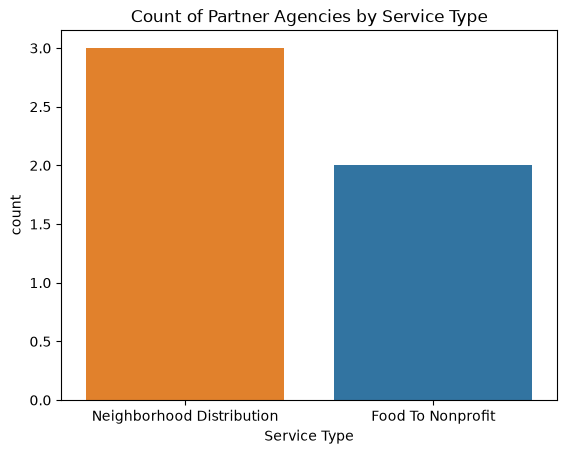

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
order1 = df["service_type"].value_counts().index
sns.countplot(data=df, x="service_type", hue="service_type", order=order1)
plt.title("Count of Partner Agencies by Service Type")
plt.xlabel("Service Type")
plt.show()

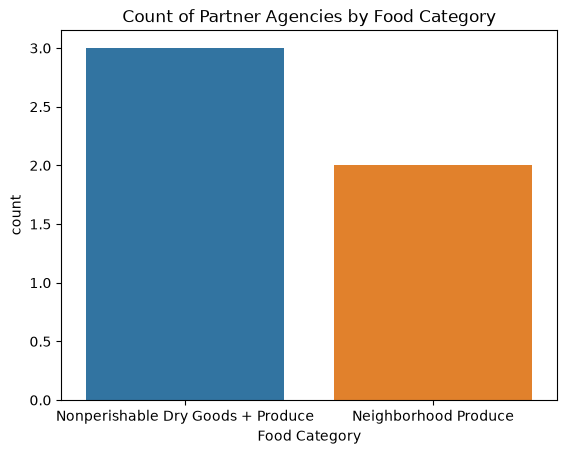

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
order2 = df["food_category"].value_counts().index
sns.countplot(data=df, x="food_category", hue="food_category", order=order2)
plt.title("Count of Partner Agencies by Food Category")
plt.xlabel("Food Category")
plt.show()

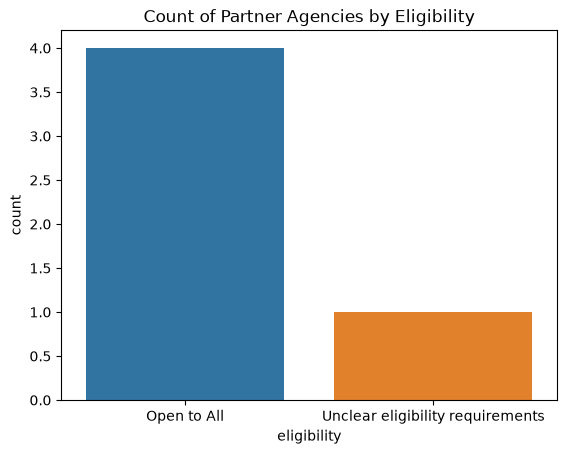

In [25]:
order3 = df["eligibility"].value_counts().index
sns.countplot(data=df, x="eligibility", hue="eligibility", order=order3)
plt.title("Count of Partner Agencies by Eligibility")
plt.xlabel("eligibility")
plt.show()

In [29]:
dayandfrequency = df.pivot_table(index="frequency", columns="distribution_day", values="name", aggfunc="count")
dayandfrequency.rename(columns={"name": "Count of Resources"})
day_order = ["Tuesday", "Wednesday", "Thursday", "Saturday"]
dayandfrequency = dayandfrequency[day_order]
dayandfrequency

distribution_day,Tuesday,Wednesday,Thursday,Saturday
frequency,,,,
Monthly,NaN,NaN,1.0,2.0
Weekly,1.0,1.0,NaN,NaN


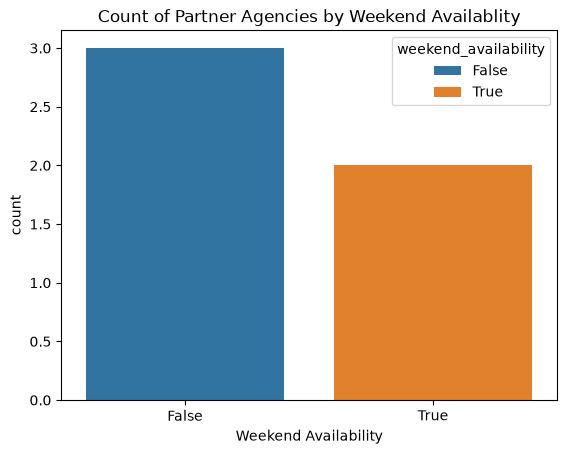

In [31]:
order4 = df["weekend_availability"].value_counts().index
sns.countplot(data=df, x="weekend_availability", hue="weekend_availability", order=order4)
plt.title("Count of Partner Agencies by Weekend Availablity")
plt.xlabel("Weekend Availability")
plt.show()

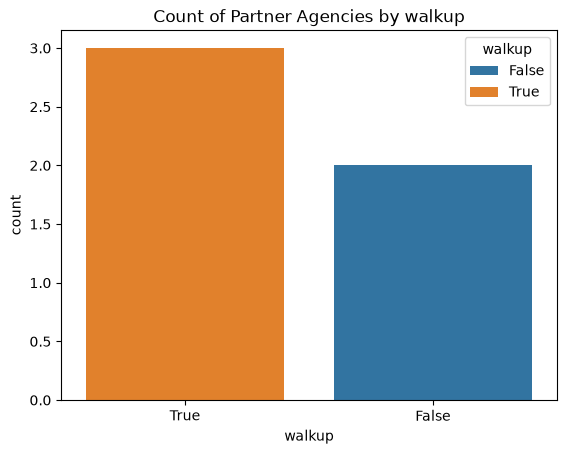

In [33]:
order5 = df["walkup"].value_counts().index
sns.countplot(data=df, x="walkup", hue="walkup", order=order5)
plt.title("Count of Partner Agencies by walkup")
plt.xlabel("walkup")
plt.show()

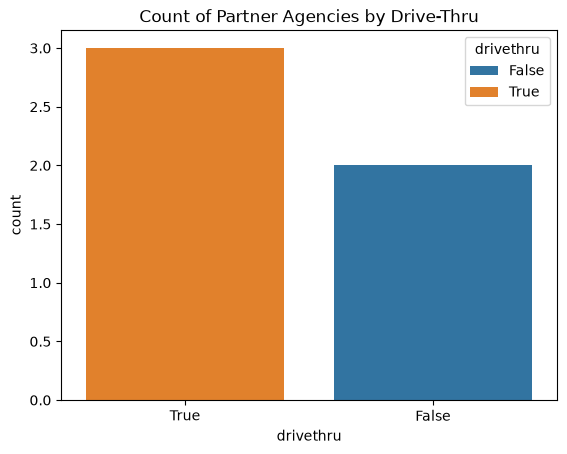

In [37]:
order6 = df["drivethru"].value_counts().index
sns.countplot(data=df, x="drivethru", hue="drivethru", order=order6)
plt.title("Count of Partner Agencies by Drive-Thru")
plt.xlabel("drivethru")
plt.show()